In [1]:
# Debt-loss dataset looking weird; let's check
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "..\output\EPO_df_debt-loss_11-17_14h2m.csv",
    index_col=[0, 1]
)
df.head()

EPOs_1    EPOs_2  true_effect
N_DISC treatment_value_idx                                 
2      0                         NaN  0.400863      0.00000
       1                    0.563340       NaN      1.00000
3      0                         NaN  0.340857      0.00000
       1                    0.524194  0.450433      0.47941
       2                    0.665055       NaN      1.00000

In [7]:
df.loc[[10]]

EPOs_1    EPOs_2  true_effect
N_DISC treatment_value_idx                                 
10     0                         NaN  0.427084     0.000000
       1                    0.583422  0.507264     0.149175
       2                    0.597637  0.513603     0.218145
       3                    0.596407  0.498458     0.310821
       4                    0.566479  0.455323     0.420720
       5                    0.542770  0.419859     0.538000
       6                    0.513214  0.370862     0.651237
       7                    0.486436  0.327479     0.750598
       8                    0.505142  0.360015     0.855259
       9                    0.670558       NaN     1.000000

In [8]:
df.loc[[10]]["EPOs_2"] - df.loc[[10]]["EPOs_1"] # Negative ATE

N_DISC  treatment_value_idx
10      0                           NaN
        1                     -0.076158
        2                     -0.084034
        3                     -0.097949
        4                     -0.111156
        5                     -0.122911
        6                     -0.142352
        7                     -0.158956
        8                     -0.145127
        9                           NaN
dtype: float64

In [12]:
df_N.loc[(10, 0), "EPOs_2"]

np.float64(0.4270842671394348)

In [42]:
# Positive ATE when subintervals shifted
N = 10
df_N = df.loc[[N]]
ates = []
for i in range(len(df_N) - 1):
    mu_0 = df_N.loc[(N, i), "EPOs_2"]
    mu_1 = df_N.loc[(N, i + 1), "EPOs_1"]
    ate = mu_1 - mu_0
    ates.append(ate)
ates

[np.float64(0.1563376784324646),
 np.float64(0.0903734564781189),
 np.float64(0.08280384540557861),
 np.float64(0.06802129745483404),
 np.float64(0.08744663000106817),
 np.float64(0.09335446357727056),
 np.float64(0.11557421088218689),
 np.float64(0.17766219377517706),
 np.float64(0.3105432987213135)]

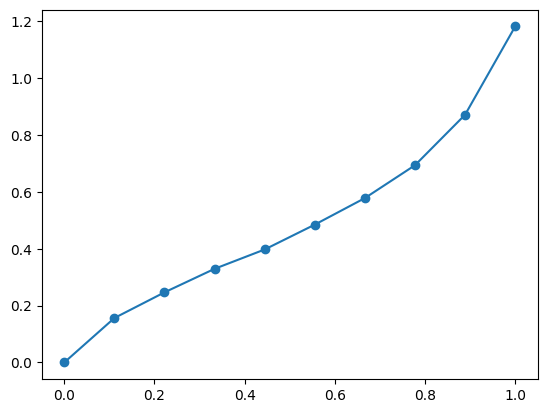

In [43]:
ate_calc = [sum(ates[:i]) for i in range(N)]

plt.plot(np.linspace(0, 1, len(ate_calc)), ate_calc, '-o')

In [ ]:
# Looks right!